In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_excel("gold_return_prediction.xlsx")
df.head()

,Date,USD_INR,Gold_USD_oz,Day,Month,Year,India_Gold_INR_gram,India_Gold_INR_10g,DoD_Change_INR_10g_%,CPI_Inflation_YoY_%,Repo_Rate_%,VIX,VIX_DoD%,Crude_Oil_USD/barrel,Crude_Oil_%DoD,NIFTY_50,NIFTY_50_%DoD,US_10Y_Treasury_Yield_%,India_BondYeilds
0,2024-01-01,83.31,2034.04,Monday,January,2024,5448.132808,54481.328081,NaN,5.1,6.5,13.20,NaN,70.62,NaN,21741.900391,NaN,3.95,7.05
1,2024-01-02,83.31,2034.04,Tuesday,January,2024,5448.132808,54481.328081,0.000000,5.1,6.5,13.20,0.000000,70.62,0.000000,21665.800781,-0.003500,3.95,7.05
2,2024-01-03,83.30,2034.04,Wednesday,January,2024,5447.478849,54474.788491,-0.000120,5.1,6.5,14.04,0.063636,72.97,0.033277,21517.349609,-0.006852,3.91,7.05
3,2024-01-04,83.21,2034.04,Thursday,January,2024,5441.593218,54415.932176,-0.001080,5.1,6.5,14.13,0.006410,72.38,-0.008086,21658.599609,0.006564,3.99,7.05
4,2024-01-05,83.16,2034.04,Friday,January,2024,5438.323422,54383.234224,-0.000601,5.1,6.5,13.35,-0.055202,74.00,0.022382,21710.800781,0.002410,4.05,7.05


In [3]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

In [4]:
df["Target_Return"] = df["DoD_Change_INR_10g_%"]

In [5]:
df["Gold_USD_lag_1"] = df["Gold_USD_oz"].shift(1)
df["USD_INR_lag_1"] = df["USD_INR"].shift(1)
df["VIX_lag_1"] = df["VIX"].shift(1)
df["NIFTY_lag_1"] = df["NIFTY_50"].shift(1)

# Gold
df["Gold_USD_lag_2"] = df["Gold_USD_oz"].shift(2)
df["Gold_USD_lag_7"] = df["Gold_USD_oz"].shift(7)

# USDINR
df["USD_INR_lag_2"] = df["USD_INR"].shift(2)

# VIX
df["VIX_lag_2"] = df["VIX"].shift(2)

# NIFTY
df["NIFTY_lag_2"] = df["NIFTY_50"].shift(2)





In [6]:
# Trend
df["gold_ma_7"] = df["Gold_USD_oz"].rolling(7).mean()
df["gold_ma_14"] = df["Gold_USD_oz"].rolling(14).mean()

# Volatility
df["gold_vol_7"] = df["Gold_USD_oz"].rolling(7).std()

# Momentum
df["gold_momentum_7"] = df["Gold_USD_oz"] - df["Gold_USD_oz"].shift(7)

In [7]:
df["gold_usd_x_inr"] = df["Gold_USD_lag_1"] * df["USD_INR_lag_1"]
df["vix_x_nifty"] = df["VIX_DoD%"] * df["NIFTY_50_%DoD"]

In [8]:
df = df.dropna().reset_index(drop=True)

In [9]:
features = [
    "Gold_USD_lag_1", "Gold_USD_lag_2", "Gold_USD_lag_7",
    "USD_INR_lag_1", "USD_INR_lag_2",
    "VIX_lag_1", "VIX_lag_2",
    "NIFTY_lag_1", "NIFTY_lag_2",

    "gold_ma_7", "gold_ma_14",
    "gold_vol_7", "gold_momentum_7",

    "gold_usd_x_inr", "vix_x_nifty",

    "VIX_DoD%",
    "Crude_Oil_%DoD",
    "NIFTY_50_%DoD",
    "US_10Y_Treasury_Yield_%",
    "India_BondYeilds"
]

X = df[features]
y = df["Target_Return"]

In [10]:
split = int(len(df) * 0.85)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [11]:
model = XGBRegressor(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=400,
             n_jobs=None, num_parallel_tree=None, ...)

In [12]:
y_pred = model.predict(X_test)

mae = np.mean(np.abs(y_test - y_pred))
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 0.01705056421891437
MAE: 0.013311329694388155


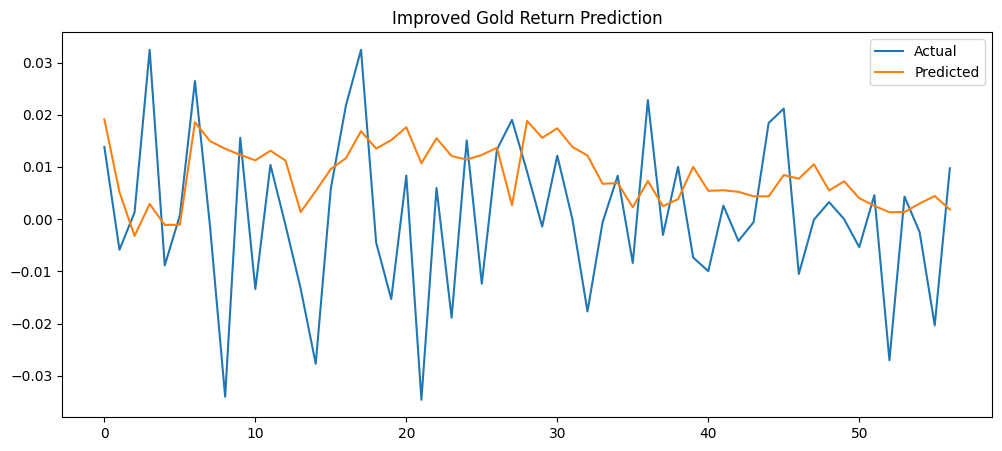

In [13]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Improved Gold Return Prediction")
plt.show()

In [14]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance

,Feature,Importance
7,NIFTY_lag_1,0.206270
2,Gold_USD_lag_7,0.083416
12,gold_momentum_7,0.082071
5,VIX_lag_1,0.074009
11,gold_vol_7,0.059863
8,NIFTY_lag_2,0.050595
1,Gold_USD_lag_2,0.049317
16,Crude_Oil_%DoD,0.047427
10,gold_ma_14,0.038409
0,Gold_USD_lag_1,0.036598
